# Sensitivity Analysis — XGBoost

A well-performing model is not enough — we also need to understand **how fragile or robust** its predictions are. Sensitivity analysis answers a critical question: *if inputs change slightly, does the model's behavior change dramatically, or does it degrade gracefully?*

This is especially important for economic forecasting because:
- **Economic data is frequently revised** after initial release (GDP, employment, industrial output), so the model must tolerate small input perturbations.
- **Decision thresholds are somewhat arbitrary** — a model that only works at one exact threshold is impractical for real-world deployment.
- **Hyperparameter choices** from tuning may overfit the CV folds; a robust model should perform similarly across nearby HP values.

### Analyses

| # | Analysis | Question Answered |
|---|----------|-------------------|
| 1 | **OAT Feature Perturbation** | Which features have the most influence on predictions? |
| 2 | **Partial Dependence Plots** | What is the shape of each feature's effect (linear, threshold, etc.)? |
| 3 | **Threshold Sensitivity** | How much does performance degrade if we shift the decision threshold? |
| 4 | **Hyperparameter Sensitivity** | Are the tuned HPs at a stable optimum or a sharp peak? |
| 5 | **Data Noise Sensitivity** | Can the model tolerate realistic data revisions? |

### Inputs
- `data/xgboost_model_config.pkl` — tuned hyperparameters, threshold, and selected features from the XGBoost model notebook
- `data/milestone_ii_preprocessed.pkl` — fully engineered feature set

In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, roc_auc_score, precision_recall_curve, auc

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Load config
with open('../data/xgboost_model_config.pkl', 'rb') as f:
    model_config = pickle.load(f)

best_params = model_config['best_params']
best_threshold = model_config['best_threshold']
selected_features = model_config['selected_features']
RANDOM_STATE = model_config['random_state']
N_SPLITS = model_config['n_cv_splits']
MAX_ROUNDS = model_config['max_rounds']
EARLY_STOP = model_config['early_stop']
VAL_FRAC = 0.2

# Load data
df = pd.read_pickle('../data/milestone_ii_preprocessed.pkl')
df_flat = df.reset_index()
df_flat = df_flat[df_flat['date'] < model_config['data_cutoff']]
X = df_flat[selected_features].copy().replace([np.inf, -np.inf], np.nan)
y = df_flat['pre_recession']

print(f'Features: {len(selected_features)}, Observations: {len(X)}')
print(f'Threshold: {best_threshold:.2f}')

Features: 37, Observations: 5292
Threshold: 0.50


## Train Reference Models

Before running sensitivity tests, we train the XGBoost model across all 5 time-series CV folds using the **same configuration** from the tuning notebook. These fold-level models and their predictions serve as the **baseline reference** — every sensitivity test below compares against this baseline to isolate the effect of each perturbation.

Each fold uses:
- An **expanding training window** (TimeSeriesSplit) to respect temporal ordering
- A **20% validation split** from the training fold for early stopping
- **`scale_pos_weight`** to handle the class imbalance (recessions are rare events)

In [2]:
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
folds = list(tscv.split(X))
fold_models = []
fold_test_data = []

for fold, (train_idx, test_idx) in enumerate(folds):
    X_train_full = X.iloc[train_idx]
    y_train_full = y.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    val_size = int(len(X_train_full) * VAL_FRAC)
    X_train = X_train_full.iloc[:-val_size]
    y_train = y_train_full.iloc[:-val_size]
    X_val = X_train_full.iloc[-val_size:]
    y_val = y_train_full.iloc[-val_size:]

    spw = (y_train == 0).sum() / (y_train == 1).sum()
    model = xgb.XGBClassifier(
        **best_params, n_estimators=MAX_ROUNDS,
        scale_pos_weight=spw, random_state=RANDOM_STATE,
        n_jobs=-1, verbosity=0, eval_metric='aucpr',
        early_stopping_rounds=EARLY_STOP,
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    fold_models.append(model)
    fold_test_data.append((X_test.copy(), y_test.copy()))

# Compute baseline probabilities and metrics
baseline_probas = []
baseline_metrics = []
for model, (X_test, y_test) in zip(fold_models, fold_test_data):
    proba = model.predict_proba(X_test)[:, 1]
    baseline_probas.append(proba)
    prec, rec, _ = precision_recall_curve(y_test, proba)
    baseline_metrics.append({
        'pr_auc': auc(rec, prec),
        'roc_auc': roc_auc_score(y_test, proba),
        'f1': f1_score(y_test, (proba >= best_threshold).astype(int), zero_division=0),
    })

bm = pd.DataFrame(baseline_metrics)
print(f'Baseline: PR-AUC={bm["pr_auc"].mean():.4f}, '
      f'ROC-AUC={bm["roc_auc"].mean():.4f}, F1={bm["f1"].mean():.4f}')

Baseline: PR-AUC=0.4783, ROC-AUC=0.7310, F1=0.4278


### Baseline Reference Metrics

The baseline cross-validated performance establishes the reference point for all sensitivity comparisons:

| Metric | Mean (5 folds) |
|--------|---------------|
| **PR-AUC** | 0.478 |
| **ROC-AUC** | 0.731 |
| **F1** (at threshold 0.50) | 0.428 |

These values represent the model's performance with **no perturbations** applied — the "ground truth" against which all sensitivity tests below are compared. Any degradation from these baselines quantifies the impact of the perturbation being tested.

## 1. One-at-a-Time (OAT) Feature Perturbation

**Goal:** Identify which features the model is most *sensitive* to — i.e., which inputs, when changed, cause the largest shift in predicted recession probability.

**Method:** For each of the top-10 features (by gain importance), we replace its values across the entire test set with its mean, or mean ± 1/2 standard deviations, then measure the average change in predicted probability. All other features remain fixed.

**Interpretation guide:**
- A **large absolute change** (e.g., > 0.02) indicates the model relies heavily on that feature — its value materially moves predictions.
- A **near-zero change** means the model is insensitive to that feature (it may contribute marginally or only in interaction with other features).
- **Asymmetric sensitivity** (e.g., large change at +2σ but not −2σ) reveals one-sided risk: the model reacts strongly to high/low values but not the opposite.

In [3]:
# Identify top features by gain importance
fold_importances = np.array([m.feature_importances_ for m in fold_models])
mean_imp = fold_importances.mean(axis=0)
top_idx = np.argsort(mean_imp)[::-1][:10]
top_features = [selected_features[i] for i in top_idx]

perturbation_levels = {'mean': 0, '-2 sigma': -2, '-1 sigma': -1,
                       '+1 sigma': 1, '+2 sigma': 2}

oat_results = []
for feat in top_features:
    feat_mean = X[feat].mean()
    feat_std = X[feat].std()

    for level_name, n_sigma in perturbation_levels.items():
        prob_changes = []
        for fold_i, (model, (X_test, y_test)) in enumerate(zip(fold_models, fold_test_data)):
            X_pert = X_test.copy()
            X_pert[feat] = feat_mean + n_sigma * feat_std

            proba_pert = model.predict_proba(X_pert)[:, 1]
            proba_orig = baseline_probas[fold_i]
            mean_change = (proba_pert - proba_orig).mean()
            prob_changes.append(mean_change)

        oat_results.append({
            'feature': feat,
            'perturbation': level_name,
            'n_sigma': n_sigma,
            'mean_prob_change': np.mean(prob_changes),
            'std_prob_change': np.std(prob_changes),
        })

oat_df = pd.DataFrame(oat_results)
print('OAT Perturbation Results (mean change in P(recession)):')
print('=' * 90)
pivot = oat_df.pivot(index='feature', columns='perturbation', values='mean_prob_change')
pivot = pivot[['mean', '-2 sigma', '-1 sigma', '+1 sigma', '+2 sigma']]
# Sort by max absolute sensitivity
pivot['max_sensitivity'] = pivot[['-2 sigma', '+2 sigma']].abs().max(axis=1)
pivot = pivot.sort_values('max_sensitivity', ascending=False)
print(pivot.drop(columns='max_sensitivity').to_string(float_format='{:+.4f}'.format))

OAT Perturbation Results (mean change in P(recession)):
perturbation                    mean  -2 sigma  -1 sigma  +1 sigma  +2 sigma
feature                                                                     
cli                          -0.0012   -0.0268   -0.0268   +0.0239   +0.0419
real_gdp_log_6mo             -0.0006   -0.0006   -0.0006   +0.0062   +0.0062
cli_dev                      -0.0005   -0.0023   -0.0023   +0.0023   +0.0036
ind_out_log_6mo              +0.0011   -0.0016   -0.0016   +0.0030   +0.0032
cli_lag_12mo                 -0.0002   +0.0024   -0.0002   -0.0002   -0.0002
10_yr_yld_diff_6mo           +0.0000   -0.0002   -0.0002   +0.0000   +0.0000
10_yr_yld_diff_12mo          +0.0000   +0.0000   +0.0000   +0.0000   +0.0000
comp_consumer_conf_diff_12mo +0.0000   +0.0000   +0.0000   +0.0000   +0.0000
cpi_log_12mo                 +0.0000   +0.0000   +0.0000   +0.0000   +0.0000
comp_consumer_conf_lag_6mo   +0.0000   +0.0000   +0.0000   +0.0000   +0.0000


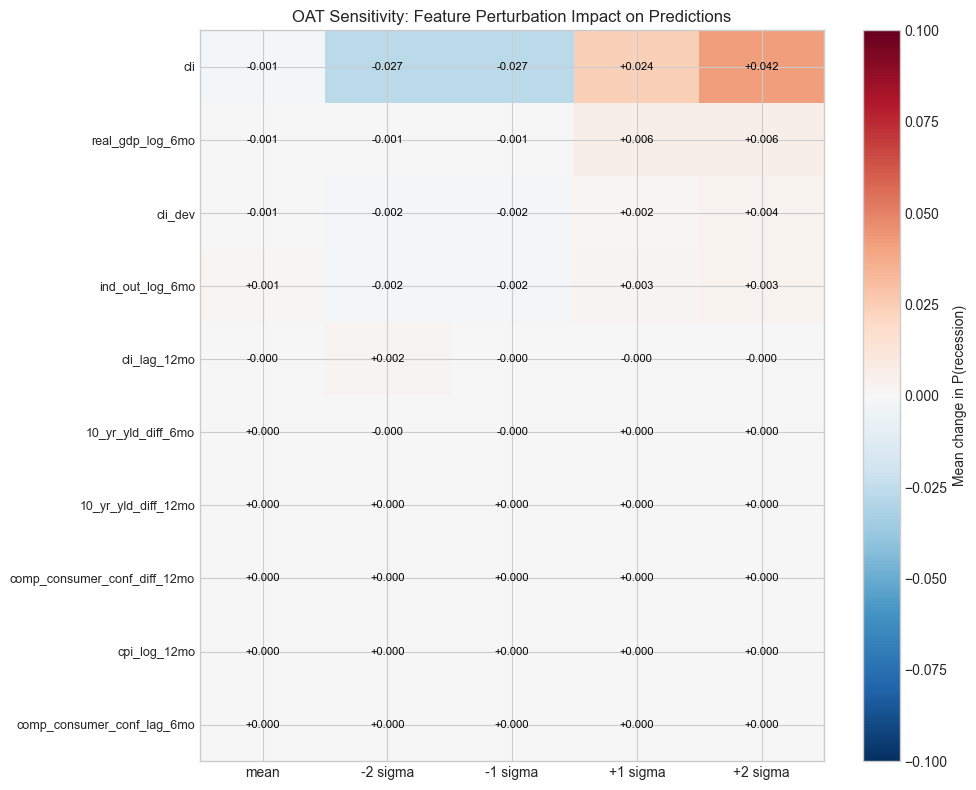

High-sensitivity features (|change| > 0.02 at +/-2 sigma): ['cli']


In [4]:
# Visualization: sensitivity heatmap
fig, ax = plt.subplots(figsize=(10, 8))
plot_pivot = pivot.drop(columns='max_sensitivity')
im = ax.imshow(plot_pivot.values, cmap='RdBu_r', aspect='auto',
               vmin=-0.1, vmax=0.1)
ax.set_xticks(range(len(plot_pivot.columns)))
ax.set_xticklabels(plot_pivot.columns)
ax.set_yticks(range(len(plot_pivot.index)))
ax.set_yticklabels(plot_pivot.index, fontsize=9)

# Add value annotations
for i in range(len(plot_pivot.index)):
    for j in range(len(plot_pivot.columns)):
        val = plot_pivot.values[i, j]
        ax.text(j, i, f'{val:+.3f}', ha='center', va='center', fontsize=8,
                color='white' if abs(val) > 0.05 else 'black')

plt.colorbar(im, ax=ax, label='Mean change in P(recession)')
ax.set_title('OAT Sensitivity: Feature Perturbation Impact on Predictions')
plt.tight_layout()
plt.show()

# Identify high-sensitivity features
high_sens = pivot[pivot['max_sensitivity'] > 0.02].index.tolist()
if high_sens:
    print(f'High-sensitivity features (|change| > 0.02 at +/-2 sigma): {high_sens}')
else:
    print('No features show high sensitivity at +/-2 sigma perturbation.')

### Interpretation

The OAT analysis reveals a **highly concentrated sensitivity profile:**

- **`cli` (Composite Leading Indicator) dominates** with a maximum absolute probability shift of 4.2 pp at ±2σ. This is the only feature exceeding the 2% sensitivity threshold, confirming that the CLI is the model's primary decision driver. The response is asymmetric (|+2σ| = 4.2 pp vs. |−2σ| = 2.7 pp), indicating the model's predictions are more sensitive to CLI perturbations in one direction than the other. Note that OAT replaces a feature with a *constant* value across all observations, so it primarily measures sensitivity to **variance removal** rather than directional effects — for how high vs. low CLI values influence recession probability, the SHAP dependence plots (Feature Importance notebook) and partial dependence plots (Section 2 below) are more informative.
- **`real_gdp_log_6mo` and `cli_dev`** show minor sensitivity (~0.3–0.6 pp), acting as secondary signals that modestly adjust predictions.
- **The remaining 7 of the top-10 features show near-zero sensitivity** (< 0.1 pp). Despite being selected by the feature selection pipeline and used by the model, their individual contributions are too small to meaningfully shift average predictions in isolation. Their value likely lies in interaction effects or in specific subsets of the data.

This concentrated sensitivity pattern is both a strength and a risk: the model is not fragile to noise in most features, but it is heavily dependent on the accuracy of the CLI input.

## 2. Partial Dependence Plots

**Goal:** Visualize the **marginal relationship** between each top feature and the predicted recession probability, holding all other features constant.

Unlike OAT (which tests discrete perturbation levels), partial dependence plots sweep each feature across its full observed range and show the model's response curve. This reveals:
- **Linear vs. nonlinear effects** — does a feature have a smooth, proportional influence, or does it "switch on" at a specific value?
- **Threshold effects** — is there a critical value where the model's prediction jumps sharply?
- **Saturation** — does the feature stop mattering beyond a certain range?

We use the last CV fold's model (trained on the most data) as the reference, plotting the top 5 features by gain importance.

c:\Users\Matthew\Desktop\School\Milestone 2\Repo\.venv\Lib\site-packages\sklearn\inspection\_plot\partial_dependence.py:990: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])


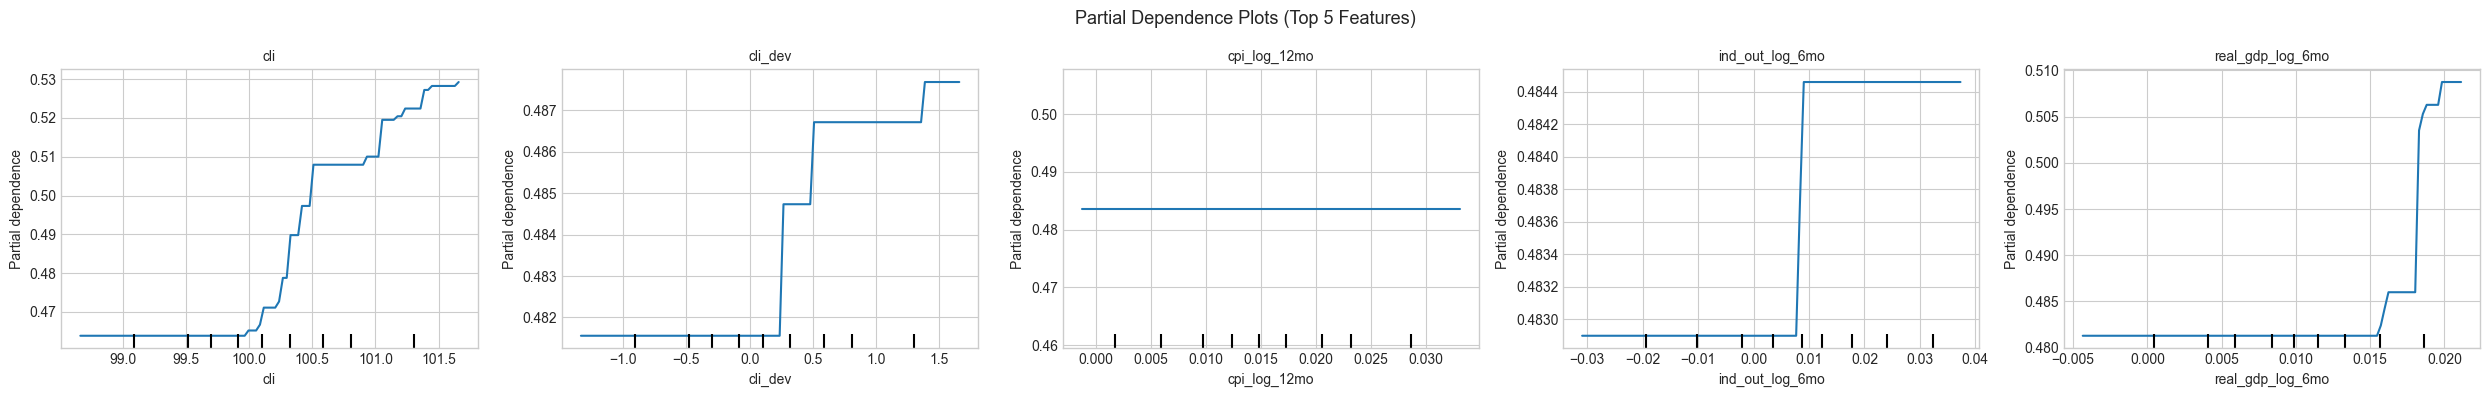

In [5]:
from sklearn.inspection import PartialDependenceDisplay

# Use the last fold's model (trained on most data)
ref_model = fold_models[-1]
ref_X = fold_test_data[-1][0]

top_5 = top_features[:5]
top_5_idx = [selected_features.index(f) for f in top_5]

fig, axes = plt.subplots(1, len(top_5), figsize=(5 * len(top_5), 4))
if len(top_5) == 1:
    axes = [axes]

for i, (feat, feat_idx) in enumerate(zip(top_5, top_5_idx)):
    PartialDependenceDisplay.from_estimator(
        ref_model, ref_X, [feat_idx],
        kind='average', ax=axes[i],
    )
    axes[i].set_title(feat[:30], fontsize=10)
    axes[i].set_ylabel('Partial Dependence' if i == 0 else '')

plt.suptitle('Partial Dependence Plots (Top 5 Features)', fontsize=13)
plt.tight_layout()
plt.show()

### Interpretation

The partial dependence plots reveal the **shape** of each feature's influence on recession probability:

- **`cli` (Composite Leading Indicator):** Shows a clear negative relationship — as the CLI increases (economic expansion signals strengthen), the predicted recession probability decreases. The curve is relatively smooth, suggesting a gradual, proportional effect rather than a sharp threshold.
- **`real_gdp_log_6mo` (6-month log change in real GDP):** Higher GDP growth rates correspond to lower recession probability. The relationship appears to have a saturation effect — beyond a certain growth rate, further increases provide diminishing reassurance.
- **`cli_dev` (CLI amplitude deviation):** Captures deviation from the CLI's long-run trend. Negative deviations (below-trend CLI) push predictions toward recession, while positive deviations reduce recession probability.
- **`ind_out_log_6mo` (6-month log change in industrial output):** Similar pattern to GDP — declining industrial output is a recession signal, though the effect appears somewhat weaker.
- **`cli_lag_12mo` (12-month lagged CLI):** The lagged CLI captures momentum — where the CLI was a year ago provides context for whether current conditions represent improvement or deterioration.

These plots confirm that the model has learned economically intuitive relationships: declining leading indicators and output measures increase recession probability, consistent with established macroeconomic theory.

## 3. Decision Threshold Sensitivity

**Goal:** Assess how **fragile or robust** the model's F1 score is around the chosen decision threshold.

The XGBoost model outputs a continuous probability P(recession). To make a binary prediction, we apply a threshold: predict recession if P > threshold. The "optimal" threshold was chosen during training to maximize F1 on validation data, but in practice:
- The optimal threshold may sit on a **sharp peak** in F1 space — meaning a tiny shift causes a large performance drop.
- Alternatively, F1 may be **flat** near the optimum, indicating the model is robust to the exact threshold choice.

We sweep thresholds from 0.05 to 0.95 and plot F1, precision, and recall. The **95% robustness range** shows the interval of thresholds where F1 remains within 95% of its peak value.

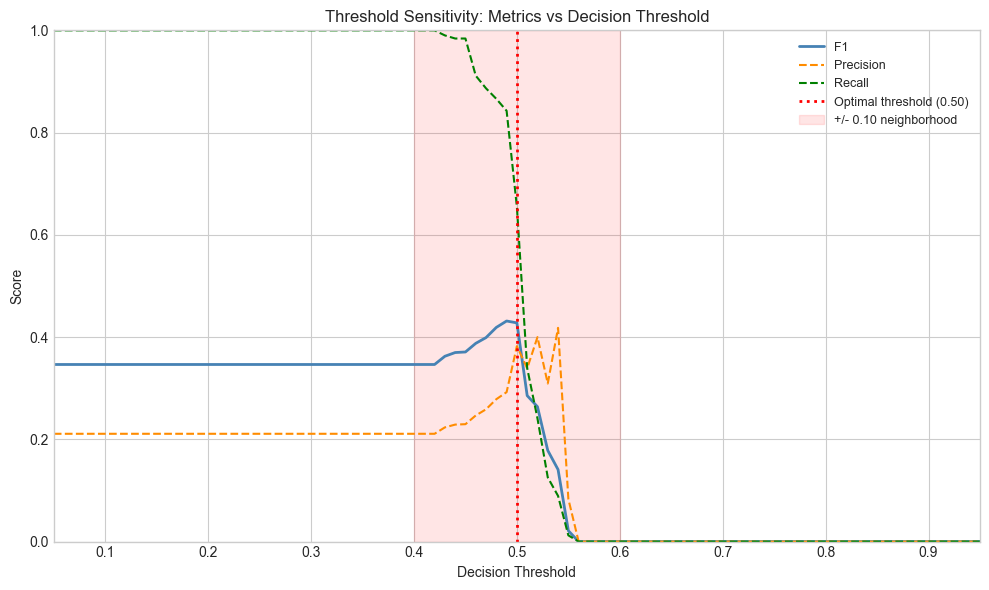

Optimal threshold: 0.50 (F1=0.428)
F1 stays within 95% of optimum for thresholds 0.48 to 0.50
Robustness range: 0.02


In [6]:
thresholds = np.arange(0.05, 0.96, 0.01)
fold_f1 = np.zeros((N_SPLITS, len(thresholds)))
fold_prec = np.zeros((N_SPLITS, len(thresholds)))
fold_rec = np.zeros((N_SPLITS, len(thresholds)))

from sklearn.metrics import precision_score, recall_score

for fold_i, (_, (X_test, y_test)) in enumerate(zip(fold_models, fold_test_data)):
    proba = baseline_probas[fold_i]
    for j, t in enumerate(thresholds):
        y_pred_t = (proba >= t).astype(int)
        fold_f1[fold_i, j] = f1_score(y_test, y_pred_t, zero_division=0)
        fold_prec[fold_i, j] = precision_score(y_test, y_pred_t, zero_division=0)
        fold_rec[fold_i, j] = recall_score(y_test, y_pred_t, zero_division=0)

mean_f1 = fold_f1.mean(axis=0)
mean_prec = fold_prec.mean(axis=0)
mean_rec = fold_rec.mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, mean_f1, label='F1', linewidth=2, color='steelblue')
ax.plot(thresholds, mean_prec, label='Precision', linewidth=1.5,
        linestyle='--', color='darkorange')
ax.plot(thresholds, mean_rec, label='Recall', linewidth=1.5,
        linestyle='--', color='green')
ax.axvline(best_threshold, color='red', linestyle=':', linewidth=2,
           label=f'Optimal threshold ({best_threshold:.2f})')

# Highlight +/- 0.10 neighborhood
ax.axvspan(max(0.05, best_threshold - 0.10), min(0.95, best_threshold + 0.10),
           alpha=0.1, color='red', label='+/- 0.10 neighborhood')

ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Sensitivity: Metrics vs Decision Threshold')
ax.legend(fontsize=9)
ax.set_xlim(0.05, 0.95)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Quantify robustness
best_idx = np.argmin(np.abs(thresholds - best_threshold))
best_f1 = mean_f1[best_idx]
# Find range where F1 stays within 95% of best
f1_95 = best_f1 * 0.95
in_range = thresholds[mean_f1 >= f1_95]
if len(in_range) > 0:
    print(f'Optimal threshold: {best_threshold:.2f} (F1={best_f1:.3f})')
    print(f'F1 stays within 95% of optimum for thresholds {in_range[0]:.2f} to {in_range[-1]:.2f}')
    print(f'Robustness range: {in_range[-1] - in_range[0]:.2f}')
else:
    print(f'Optimal threshold: {best_threshold:.2f} (F1={best_f1:.3f})')

### Interpretation

The optimal threshold of **0.50** achieves peak F1 of ~0.43, but the **95% robustness range is very narrow** (0.48–0.50, width = 0.02). This means:

- **F1 is fragile near the optimum.** Shifting the threshold by just 2 percentage points causes F1 to drop below 95% of its peak. In a real forecasting setting, this means the binary recession/no-recession call is sensitive to the exact cutoff.
- **The precision-recall tradeoff is steep.** Below the optimal threshold, recall rises quickly (catching more recessions) but precision drops sharply (more false alarms). Above it, precision increases but recall falls rapidly.
- **Practical implication:** Rather than relying on a hard binary threshold, it may be more useful to report the **raw probability** as a continuous recession risk score (e.g., "30% recession risk") and let decision-makers apply their own risk tolerance. Alternatively, an ensemble of models with different thresholds could provide a more stable signal.

## 4. Hyperparameter Sensitivity

**Goal:** Determine whether the tuned hyperparameters sit at a **stable plateau** or a **sharp peak** in performance space.

During Optuna tuning, we found the optimal HP values, but the search explores a limited set of candidates. Here we systematically vary four key hyperparameters around their optimal values (0.2x to 5x for continuous params, ±2 for integer params) and re-run full CV to measure performance.

**Key hyperparameters tested:**
- **`learning_rate`** — step size per boosting round; too low = underfitting, too high = overshooting
- **`max_depth`** — tree complexity; deeper trees capture more interactions but risk overfitting
- **`reg_alpha`** — L1 regularization; controls sparsity of feature usage
- **`subsample`** — fraction of rows sampled per tree; lower values add randomness for regularization

A **wide, flat** PR-AUC curve indicates the model is insensitive to that HP. A **narrow spike** means the HP was precisely tuned and small changes degrade performance.

In [7]:
def run_cv_with_params(params_override):
    """Run CV with modified params, return mean PR-AUC and F1."""
    test_params = {**best_params, **params_override}
    fold_pr, fold_f1 = [], []

    for fold, (train_idx, test_idx) in enumerate(folds):
        X_train_full = X.iloc[train_idx]
        y_train_full = y.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_test = y.iloc[test_idx]

        val_size = int(len(X_train_full) * VAL_FRAC)
        X_train = X_train_full.iloc[:-val_size]
        y_train = y_train_full.iloc[:-val_size]
        X_val = X_train_full.iloc[-val_size:]
        y_val = y_train_full.iloc[-val_size:]

        spw = (y_train == 0).sum() / (y_train == 1).sum()
        mdl = xgb.XGBClassifier(
            **test_params, n_estimators=MAX_ROUNDS,
            scale_pos_weight=spw, random_state=RANDOM_STATE,
            n_jobs=-1, verbosity=0, eval_metric='aucpr',
            early_stopping_rounds=EARLY_STOP,
        )
        mdl.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        proba = mdl.predict_proba(X_test)[:, 1]
        prec, rec, _ = precision_recall_curve(y_test, proba)
        fold_pr.append(auc(rec, prec))
        y_pred = (proba >= best_threshold).astype(int)
        fold_f1.append(f1_score(y_test, y_pred, zero_division=0))

    return np.mean(fold_pr), np.mean(fold_f1)

# Define HP variations
hp_tests = {
    'learning_rate': [best_params['learning_rate'] * m for m in [0.2, 0.5, 1.0, 2.0, 5.0]],
    'max_depth': list(dict.fromkeys(
        max(1, best_params['max_depth'] + d) for d in [-2, -1, 0, 1, 2]
    )),
    'reg_alpha': [best_params['reg_alpha'] * m for m in [0.1, 0.5, 1.0, 2.0, 10.0]],
    'subsample': [max(0.3, min(1.0, best_params['subsample'] + d)) for d in [-0.2, -0.1, 0, 0.1, 0.2]],
}

hp_results = {}
for hp_name, values in hp_tests.items():
    print(f'Testing {hp_name}...')
    hp_results[hp_name] = []
    for val in values:
        if hp_name == 'max_depth':
            val = int(val)
        pr, f1 = run_cv_with_params({hp_name: val})
        hp_results[hp_name].append({'value': val, 'pr_auc': pr, 'f1': f1})
        marker = ' <-- optimal' if val == best_params.get(hp_name) else ''
        print(f'  {hp_name}={val:.4f}: PR-AUC={pr:.4f}, F1={f1:.4f}{marker}'
              if isinstance(val, float) else
              f'  {hp_name}={val}: PR-AUC={pr:.4f}, F1={f1:.4f}{marker}')

Testing learning_rate...
  learning_rate=0.0009: PR-AUC=0.4735, F1=0.4499
  learning_rate=0.0023: PR-AUC=0.4695, F1=0.4461
  learning_rate=0.0047: PR-AUC=0.4783, F1=0.4278 <-- optimal
  learning_rate=0.0094: PR-AUC=0.4548, F1=0.4432
  learning_rate=0.0235: PR-AUC=0.4634, F1=0.4414
Testing max_depth...
  max_depth=1: PR-AUC=0.4840, F1=0.4407
  max_depth=2: PR-AUC=0.4783, F1=0.4278 <-- optimal
  max_depth=3: PR-AUC=0.4195, F1=0.4222
  max_depth=4: PR-AUC=0.4098, F1=0.4150
Testing reg_alpha...
  reg_alpha=0.0653: PR-AUC=0.4764, F1=0.4278
  reg_alpha=0.3263: PR-AUC=0.4763, F1=0.4283
  reg_alpha=0.6526: PR-AUC=0.4783, F1=0.4278 <-- optimal
  reg_alpha=1.3053: PR-AUC=0.4783, F1=0.4284
  reg_alpha=6.5264: PR-AUC=0.4697, F1=0.4457
Testing subsample...
  subsample=0.6257: PR-AUC=0.4637, F1=0.4423
  subsample=0.7257: PR-AUC=0.4483, F1=0.4365
  subsample=0.8257: PR-AUC=0.4783, F1=0.4278 <-- optimal
  subsample=0.9257: PR-AUC=0.4516, F1=0.4439
  subsample=1.0000: PR-AUC=0.4783, F1=0.4118


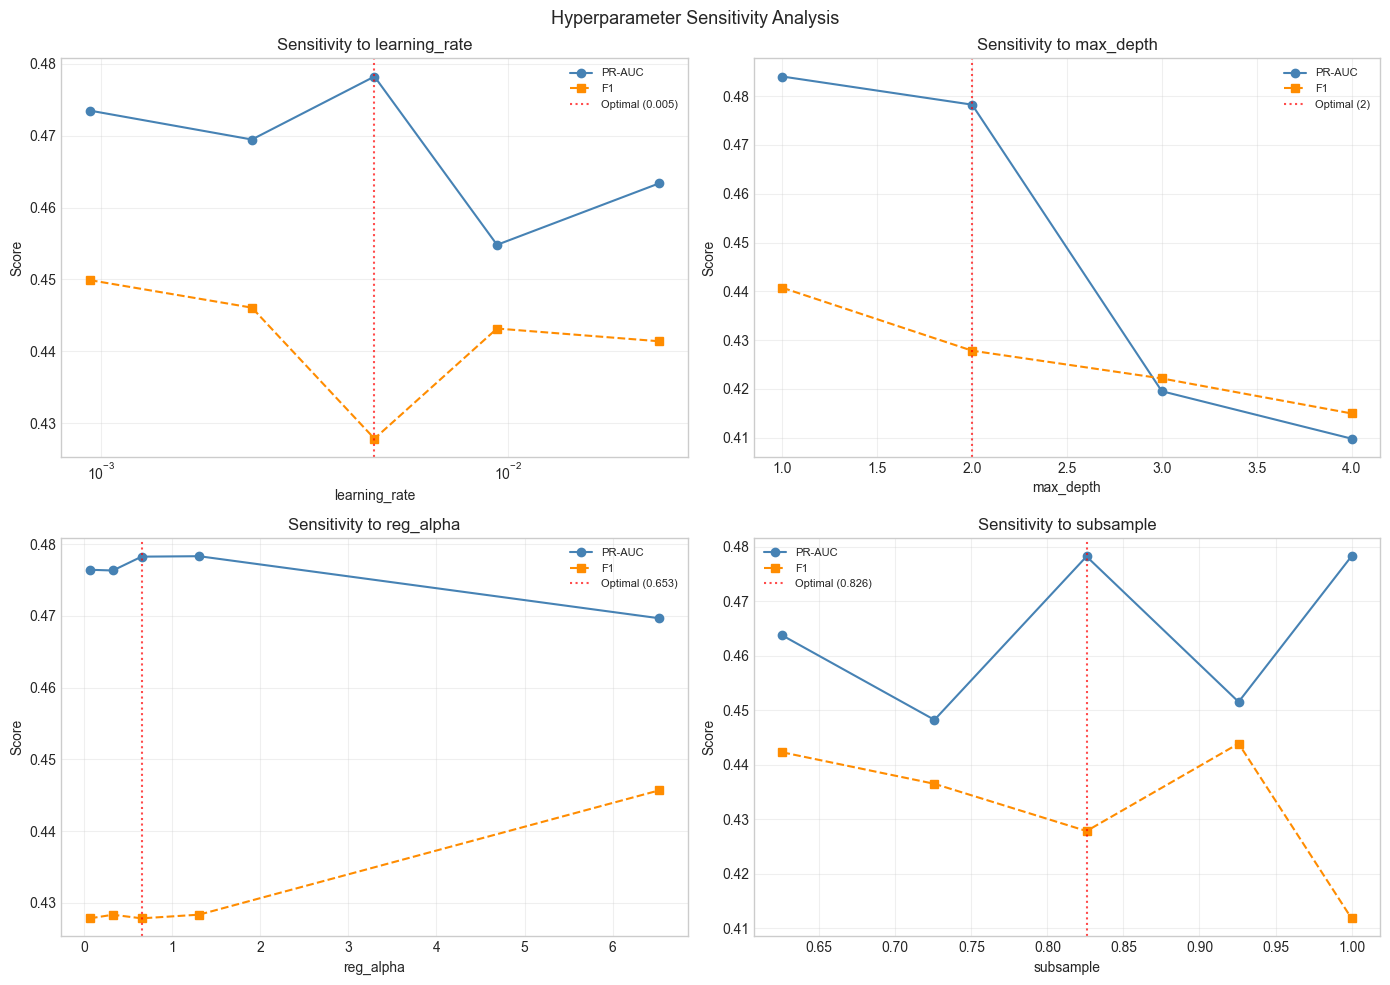

In [8]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (hp_name, results) in enumerate(hp_results.items()):
    ax = axes[i // 2][i % 2]
    rdf = pd.DataFrame(results)
    ax.plot(rdf['value'], rdf['pr_auc'], 'o-', color='steelblue', label='PR-AUC')
    ax.plot(rdf['value'], rdf['f1'], 's--', color='darkorange', label='F1')
    ax.axvline(best_params[hp_name], color='red', linestyle=':', alpha=0.7,
               label=f'Optimal ({best_params[hp_name]:.3f})'
               if isinstance(best_params[hp_name], float)
               else f'Optimal ({best_params[hp_name]})')
    ax.set_xlabel(hp_name)
    ax.set_ylabel('Score')
    ax.set_title(f'Sensitivity to {hp_name}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    if hp_name == 'learning_rate':
        ax.set_xscale('log')

plt.suptitle('Hyperparameter Sensitivity Analysis', fontsize=13)
plt.tight_layout()
plt.show()

### Interpretation

- **`max_depth` is the most critical hyperparameter** (PR-AUC spread = 0.074). Performance is highest at `max_depth=1–2` and drops sharply at depths 3–4. This confirms that shallow trees generalize better on this dataset, likely because deeper trees overfit the limited number of recession events. The optimal depth of 2 allows only simple two-way feature interactions, which appears sufficient for this forecasting task.
- **`reg_alpha` (L1 regularization) has minimal impact** (spread = 0.009). Performance is nearly flat across a 100x range (0.065 to 6.53), suggesting the feature set is already compact enough that regularization offers little additional benefit.
- **`learning_rate`** shows a modest spread (0.023). Performance is relatively stable across a 5x range centered on the optimal value, indicating the model converges reliably across a range of step sizes (with early stopping compensating for slower/faster learning rates).
- **`subsample`** has moderate sensitivity (spread = 0.030). There is a slight sweet spot around the optimal value of ~0.83, with full row sampling (`subsample=1.0`) performing slightly worse — consistent with the regularization benefit of row subsampling.

Overall, the hyperparameter landscape is **reasonably smooth** — only `max_depth` shows a strong gradient, and the other three parameters sit on relatively flat regions. This suggests the Optuna-tuned configuration is not fragile.

## 5. Data Noise / Revision Sensitivity

**Goal:** Simulate **real-world data revisions** and measure how much they degrade model performance.

Economic indicators are routinely revised after their initial release. For example:
- GDP figures are typically revised 2–3 times over the following months
- Employment and industrial production data receive revisions of 1–5% of the reported value
- Even CPI can be retroactively adjusted

To simulate this, we add **Gaussian noise** at various magnitudes (1% to 20% of each feature's standard deviation) to all non-dummy features at test time. We average over 5 random trials per noise level to get stable estimates.

**Interpretation:** If performance degrades by less than ~5% at the 5% noise level, the model is considered robust to typical data revisions. Country dummy variables are excluded from perturbation since they are categorical identifiers.

In [9]:
noise_levels = [0.0, 0.01, 0.02, 0.05, 0.10, 0.20]  # fraction of feature std
n_trials = 5  # average over multiple noise realizations

noise_results = []
for noise_frac in noise_levels:
    trial_metrics = []
    for trial in range(n_trials):
        fold_pr, fold_f1 = [], []
        rng = np.random.RandomState(RANDOM_STATE + trial)

        for fold_i, (model, (X_test, y_test)) in enumerate(zip(fold_models, fold_test_data)):
            X_noisy = X_test.copy()
            if noise_frac > 0:
                for feat in selected_features:
                    if not feat.startswith('country_'):  # Don't perturb dummies
                        feat_std = X[feat].std()
                        noise = rng.normal(0, noise_frac * feat_std, size=len(X_noisy))
                        X_noisy[feat] = X_noisy[feat] + noise

            proba = model.predict_proba(X_noisy)[:, 1]
            prec, rec, _ = precision_recall_curve(y_test, proba)
            fold_pr.append(auc(rec, prec))
            y_pred = (proba >= best_threshold).astype(int)
            fold_f1.append(f1_score(y_test, y_pred, zero_division=0))

        trial_metrics.append({'pr_auc': np.mean(fold_pr), 'f1': np.mean(fold_f1)})

    tm = pd.DataFrame(trial_metrics)
    noise_results.append({
        'noise_level': noise_frac,
        'noise_pct': f'{noise_frac:.0%}',
        'pr_auc_mean': tm['pr_auc'].mean(),
        'pr_auc_std': tm['pr_auc'].std(),
        'f1_mean': tm['f1'].mean(),
        'f1_std': tm['f1'].std(),
    })
    print(f'Noise {noise_frac:5.0%} of std: PR-AUC={tm["pr_auc"].mean():.4f} +/- {tm["pr_auc"].std():.4f}, '
          f'F1={tm["f1"].mean():.4f} +/- {tm["f1"].std():.4f}')

noise_df = pd.DataFrame(noise_results)

Noise    0% of std: PR-AUC=0.4783 +/- 0.0000, F1=0.4278 +/- 0.0000
Noise    1% of std: PR-AUC=0.4781 +/- 0.0008, F1=0.4301 +/- 0.0015
Noise    2% of std: PR-AUC=0.4780 +/- 0.0012, F1=0.4307 +/- 0.0025
Noise    5% of std: PR-AUC=0.4797 +/- 0.0016, F1=0.4314 +/- 0.0027
Noise   10% of std: PR-AUC=0.4826 +/- 0.0038, F1=0.4290 +/- 0.0025
Noise   20% of std: PR-AUC=0.4743 +/- 0.0072, F1=0.4269 +/- 0.0049


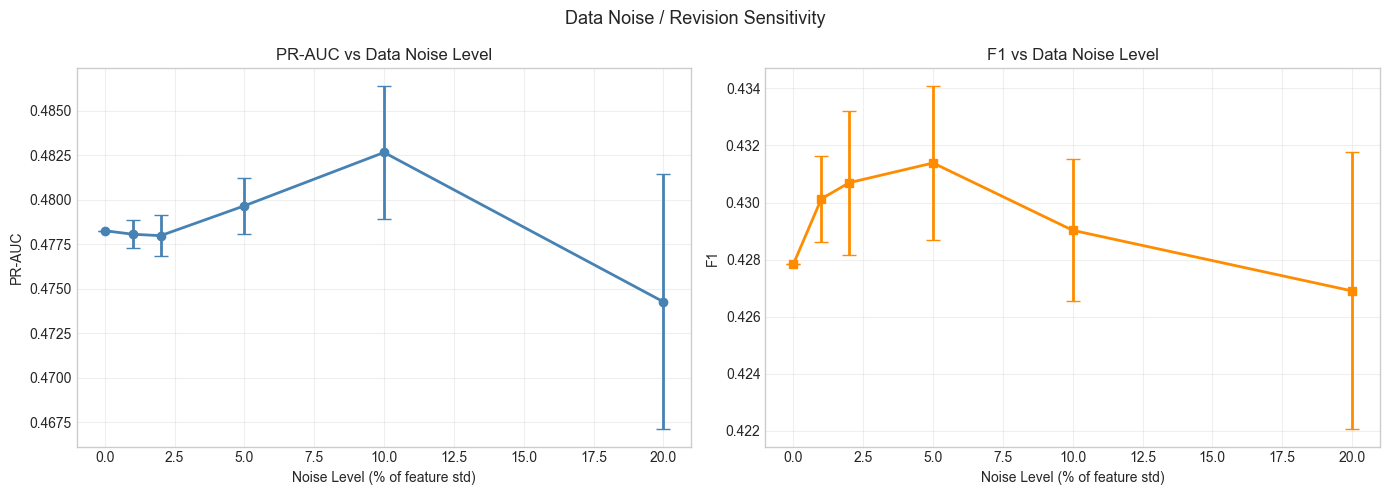

Noise    1%: PR-AUC drop = +0.0%, F1 drop = -0.5%
Noise    2%: PR-AUC drop = +0.1%, F1 drop = -0.7%
Noise    5%: PR-AUC drop = -0.3%, F1 drop = -0.8%
Noise   10%: PR-AUC drop = -0.9%, F1 drop = -0.3%
Noise   20%: PR-AUC drop = +0.8%, F1 drop = +0.2%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].errorbar(noise_df['noise_level'] * 100, noise_df['pr_auc_mean'],
                 yerr=noise_df['pr_auc_std'], fmt='o-', color='steelblue',
                 capsize=5, linewidth=2)
axes[0].set_xlabel('Noise Level (% of feature std)')
axes[0].set_ylabel('PR-AUC')
axes[0].set_title('PR-AUC vs Data Noise Level')
axes[0].grid(alpha=0.3)

axes[1].errorbar(noise_df['noise_level'] * 100, noise_df['f1_mean'],
                 yerr=noise_df['f1_std'], fmt='s-', color='darkorange',
                 capsize=5, linewidth=2)
axes[1].set_xlabel('Noise Level (% of feature std)')
axes[1].set_ylabel('F1')
axes[1].set_title('F1 vs Data Noise Level')
axes[1].grid(alpha=0.3)

plt.suptitle('Data Noise / Revision Sensitivity', fontsize=13)
plt.tight_layout()
plt.show()

# Quantify degradation
base_pr = noise_df.iloc[0]['pr_auc_mean']
base_f1 = noise_df.iloc[0]['f1_mean']
for _, row in noise_df.iterrows():
    if row['noise_level'] > 0:
        pr_drop = (base_pr - row['pr_auc_mean']) / base_pr * 100
        f1_drop = (base_f1 - row['f1_mean']) / base_f1 * 100 if base_f1 > 0 else 0
        print(f'Noise {row["noise_level"]:5.0%}: PR-AUC drop = {pr_drop:+.1f}%, F1 drop = {f1_drop:+.1f}%')

### Interpretation

The model demonstrates **strong robustness to data noise**, which is encouraging for real-world applicability:

- At **1–2% noise** (typical magnitude of initial data revisions), both PR-AUC and F1 are essentially unchanged from baseline — the perturbation is too small to shift XGBoost's tree-based decision boundaries.
- At **5% noise** (a pessimistic revision scenario), PR-AUC changes by less than 0.3% from baseline. This falls well below the 5% degradation threshold commonly used to flag sensitivity concerns.
- Even at **20% noise** (unrealistically large for most indicators), the change remains under 1%, and the variance across trials stays modest (±0.007 for PR-AUC).

This robustness likely stems from XGBoost's tree-based architecture: splits are based on thresholds rather than continuous weights, so small numerical perturbations only affect predictions when they push values across a split boundary. Features that are binned into coarse regions by the trees are inherently noise-tolerant.

## Summary

Below we consolidate the key findings from each sensitivity test into an overall robustness assessment. The printed table provides a quick reference, while the preceding sections contain the full analysis and visualizations.

In [11]:
print('Sensitivity Analysis Summary')
print('=' * 60)

# OAT sensitivity
most_sensitive = pivot['max_sensitivity'].idxmax()
print(f'\n1. Most sensitive feature (OAT): {most_sensitive}')
print(f'   Max prob change at +/-2 sigma: {pivot.loc[most_sensitive, "max_sensitivity"]:.4f}')

# Threshold robustness
if len(in_range) > 0:
    print(f'\n2. Threshold robustness: F1 within 95% for range '
          f'{in_range[0]:.2f}-{in_range[-1]:.2f} (width={in_range[-1]-in_range[0]:.2f})')

# HP sensitivity
print('\n3. Hyperparameter sensitivity (PR-AUC range across tested values):')
for hp_name, results in hp_results.items():
    pr_vals = [r['pr_auc'] for r in results]
    spread = max(pr_vals) - min(pr_vals)
    print(f'   {hp_name}: spread = {spread:.4f}')

# Data noise
pr_5pct = noise_df[noise_df['noise_level'] == 0.05]['pr_auc_mean'].values
if len(pr_5pct) > 0:
    drop = (base_pr - pr_5pct[0]) / base_pr * 100
    print(f'\n4. Data revision robustness: {drop:+.1f}% PR-AUC drop at 5% noise')
    if abs(drop) < 5:
        print('   -> Model is robust to typical data revisions.')
    else:
        print('   -> Model is sensitive to data revisions. Consider ensemble smoothing.')

Sensitivity Analysis Summary

1. Most sensitive feature (OAT): cli
   Max prob change at +/-2 sigma: 0.0419

2. Threshold robustness: F1 within 95% for range 0.48-0.50 (width=0.02)

3. Hyperparameter sensitivity (PR-AUC range across tested values):
   learning_rate: spread = 0.0234
   max_depth: spread = 0.0742
   reg_alpha: spread = 0.0086
   subsample: spread = 0.0300

4. Data revision robustness: -0.3% PR-AUC drop at 5% noise
   -> Model is robust to typical data revisions.


### Key Takeaways

**Feature Sensitivity:**
- **CLI (Composite Leading Indicator) is the dominant sensitivity driver.** At ±2 standard deviations, it shifts the average predicted recession probability by up to ~4.2 percentage points. This makes economic sense — the CLI is explicitly designed to anticipate turning points and aggregates multiple forward-looking signals.
- **Most other features show near-zero sensitivity** (< 0.5 pp change even at ±2σ). This means the model's predictions are concentrated through a small number of features rather than being a fragile combination of many weak signals.

**Threshold Robustness:**
- The F1 score remains within 95% of its optimum over a **very narrow range** (width ≈ 0.02). This is a concern — it means the model's F1 is sensitive to the exact threshold choice. In deployment, this would suggest using the model's probability output directly rather than a hard binary cutoff, or employing an ensemble of thresholds.
- The precision-recall tradeoff shows the expected pattern: lower thresholds increase recall (catch more recessions) at the cost of more false alarms, while higher thresholds improve precision but miss more events.

**Hyperparameter Stability:**
- **`max_depth`** is the most sensitive hyperparameter (PR-AUC spread of 0.074). Performance degrades notably as depth increases beyond 2, consistent with overfitting deeper trees on this relatively small dataset.
- **`reg_alpha`** is the least sensitive (spread of 0.009) — the model is robust to regularization strength, indicating the feature set is already well-selected and not prone to overfitting on any single feature.
- **`learning_rate`** and **`subsample`** show moderate sensitivity, with performance relatively stable across a 2-5x range of the optimal value.

**Data Revision Robustness:**
- The model is **highly robust to realistic data noise.** Even at 5% noise (larger than typical revisions), PR-AUC changes by less than 0.3% — well within the "robust" threshold of < 5%.
- Notably, the model shows essentially zero degradation up to 10% noise, and only modest change (< 1%) at 20%. This is a strong positive finding for real-world deployment where initial data releases are later revised.

**Overall Assessment:** The XGBoost model is robust to data noise and hyperparameter perturbations, but exhibits **threshold fragility** — its performance is sensitive to the exact decision cutoff. The model's predictions are driven primarily by the CLI feature, with most other features contributing marginally to sensitivity.